In [6]:
import numpy as np
import time
from tqdm.auto import tqdm, trange

from robofin.robots import FrankaRobot, FrankaGripper
from robofin.bullet import Bullet, BulletController

from pathlib import Path
from geometrout.primitive import Cuboid, Cylinder
from geometrout.transform import SE3

import pickle
from dataclasses import dataclass, field
from typing import List, Union, Optional, Dict
import argparse
import sys

import torch
from utils import FrankaSampler
from mpinets.model import MotionPolicyNetwork
from mpinets.geometry import construct_mixed_point_cloud
from mpinets.utils import normalize_franka_joints, unnormalize_franka_joints
from mpinets.metrics import Evaluator
from mpinets.mpinets_types import PlanningProblem, ProblemSet
import trimesh
import meshcat
import urchin

END_EFFECTOR_FRAME = "right_gripper"
NUM_ROBOT_POINTS = 2048
NUM_OBSTACLE_POINTS = 4096
NUM_TARGET_POINTS = 128
MAX_ROLLOUT_LENGTH = 150


def get_tool_parameters(problem, device="cuda:0"):
    """
    Extract tool parameters for either single primitive or composite tools
    Returns tensors for compatibility with sampling functions
    """
    if problem.tool is None:
        # No tool
        return {
            "is_composite": False,
            "tool_dims": [0.0, 0.0, 0.0],
            "tool_offsets": [0.0, 0.0, 0.0],
            "tool_quats": [1.0, 0.0, 0.0, 0.0],
            "tool_num_primitives": 0,
        }

    primitives = problem.tool.primitives
    if len(primitives) == 1:
        # Single primitive tool
        primitive = primitives[0]
        return {
            "is_composite": False,
            "tool_dims": primitive["dims"],
            "tool_offsets": primitive["offset"],
            "tool_quats": primitive["offset_quaternion"],
            "tool_num_primitives": 1,
        }
    else:
        # Composite tool with multiple primitives
        tool_dims = []
        tool_offsets = []
        tool_quats = []

        for primitive in primitives:
            tool_dims.append(primitive["dims"])
            tool_offsets.append(primitive["offset"])
            tool_quats.append(primitive["offset_quaternion"])

        return {
            "is_composite": True,
            "tool_dims": tool_dims,
            "tool_offsets": tool_offsets,
            "tool_quats": tool_quats,
            "tool_num_primitives": len(primitives),
        }


def sample_robot_points(gpu_fk_sampler, config, tool_params, num_points):
    """Sample robot points with appropriate method based on tool type"""
    # Convert to tensors
    device = config.device
    dtype = config.dtype

    # For both composite and single primitive, we use sample_composite
    # For single primitive, wrap parameters in lists
    if tool_params["is_composite"] and tool_params["tool_num_primitives"] > 0:
        tool_dims = tool_params["tool_dims"]
        tool_offsets = tool_params["tool_offsets"]
        tool_quats = tool_params["tool_quats"]
    else:
        # Single primitive - wrap in lists
        if tool_params["tool_num_primitives"] > 0:
            tool_dims = [tool_params["tool_dims"]]
            tool_offsets = [tool_params["tool_offsets"]]
            tool_quats = [tool_params["tool_quats"]]
        else:
            # No tool
            tool_dims = []
            tool_offsets = []
            tool_quats = []

    tool_dims_tensor = torch.tensor(tool_dims, dtype=dtype, device=device)
    tool_offsets_tensor = torch.tensor(tool_offsets, dtype=dtype, device=device)
    tool_quats_tensor = torch.tensor(tool_quats, dtype=dtype, device=device)
    tool_num_primitives_tensor = torch.tensor(
        len(tool_dims), dtype=torch.long, device=device
    )

    return gpu_fk_sampler.sample_composite(
        config,
        tool_dims_tensor,
        tool_offsets_tensor,
        tool_quats_tensor,
        tool_num_primitives_tensor,
        num_points,
    )


def sample_target_points(gpu_fk_sampler, pose, tool_params, num_points):
    """Sample target points with appropriate method based on tool type"""
    # Convert to tensors
    device = pose.device
    dtype = pose.dtype

    # For both composite and single primitive, we use sample_composite_end_effector
    # For single primitive, wrap parameters in lists
    if tool_params["is_composite"] and tool_params["tool_num_primitives"] > 0:
        tool_dims = tool_params["tool_dims"]
        tool_offsets = tool_params["tool_offsets"]
        tool_quats = tool_params["tool_quats"]
    else:
        # Single primitive - wrap in lists
        if tool_params["tool_num_primitives"] > 0:
            tool_dims = [tool_params["tool_dims"]]
            tool_offsets = [tool_params["tool_offsets"]]
            tool_quats = [tool_params["tool_quats"]]
        else:
            # No tool
            tool_dims = []
            tool_offsets = []
            tool_quats = []

    tool_dims_tensor = torch.tensor(tool_dims, dtype=dtype, device=device)
    tool_offsets_tensor = torch.tensor(tool_offsets, dtype=dtype, device=device)
    tool_quats_tensor = torch.tensor(tool_quats, dtype=dtype, device=device)
    tool_num_primitives_tensor = torch.tensor(
        len(tool_dims), dtype=torch.long, device=device
    )

    return gpu_fk_sampler.sample_composite_end_effector(
        pose,
        tool_dims_tensor,
        tool_offsets_tensor,
        tool_quats_tensor,
        tool_num_primitives_tensor,
        num_points,
    )


def make_point_cloud_from_problem(
    q0: torch.Tensor,
    target: SE3,
    obstacle_points: np.ndarray,
    fk_sampler: FrankaSampler,
    tool_params: dict,
) -> torch.Tensor:
    robot_points = sample_robot_points(
        fk_sampler, q0, tool_params, NUM_ROBOT_POINTS
    ).squeeze(0)

    target_points = sample_target_points(
        fk_sampler,
        torch.as_tensor(target.matrix).type_as(robot_points).unsqueeze(0),
        tool_params,
        NUM_TARGET_POINTS,
    ).squeeze(0)

    xyz = torch.cat(
        (
            torch.zeros(NUM_ROBOT_POINTS, 4),
            torch.ones(NUM_OBSTACLE_POINTS, 4),
            2 * torch.ones(NUM_TARGET_POINTS, 4),
        ),
        dim=0,
    )
    xyz[:NUM_ROBOT_POINTS, :3] = robot_points.float()
    random_obstacle_indices = np.random.choice(
        len(obstacle_points), size=NUM_OBSTACLE_POINTS, replace=False
    )
    xyz[
        NUM_ROBOT_POINTS : NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS,
        :3,
    ] = torch.as_tensor(obstacle_points[random_obstacle_indices, :3]).float()
    xyz[
        NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS :,
        :3,
    ] = target_points.float()
    return xyz


def make_point_cloud_from_primitives(
    q0: torch.Tensor,
    target: SE3,
    obstacles: List[Union[Cuboid, Cylinder]],
    fk_sampler: FrankaSampler,
    tool_params: dict,
) -> torch.Tensor:
    """
    Creates the pointcloud of the scene, including the target and the robot. When performing
    a rollout, the robot points will be replaced based on the model's prediction

    :param q0 torch.Tensor: The starting configuration (dimensions [1 x 7])
    :param target SE3: The target pose in the `right_gripper` frame
    :param obstacles List[Union[Cuboid, Cylinder]]: The obstacles in the scene
    :param fk_sampler FrankaSampler: A sampler that produces points on the robot's surface
    :param tool_params dict: Tool parameters from get_tool_parameters
    :rtype torch.Tensor: The pointcloud (dimensions
                         [1 x NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS + NUM_TARGET_POINTS x 4])
    """
    obstacle_points = construct_mixed_point_cloud(obstacles, NUM_OBSTACLE_POINTS)
    robot_points = sample_robot_points(
        fk_sampler, q0, tool_params, NUM_ROBOT_POINTS
    ).squeeze(0)

    target_points = sample_target_points(
        fk_sampler,
        torch.as_tensor(target.matrix).type_as(robot_points).unsqueeze(0),
        tool_params,
        NUM_TARGET_POINTS,
    ).squeeze(0)

    xyz = torch.cat(
        (
            torch.zeros(NUM_ROBOT_POINTS, 4),
            torch.ones(NUM_OBSTACLE_POINTS, 4),
            2 * torch.ones(NUM_TARGET_POINTS, 4),
        ),
        dim=0,
    )
    xyz[:NUM_ROBOT_POINTS, :3] = robot_points.float()
    xyz[
        NUM_ROBOT_POINTS : NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS,
        :3,
    ] = torch.as_tensor(obstacle_points[:, :3]).float()
    xyz[
        NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS :,
        :3,
    ] = target_points.float()
    return xyz

In [7]:
# Load a problem set
import mpinets.mpinets_types as mpinets_types
problem_path = Path(
    "/home/zippingsugar/Programs/motion-policy-networks/problems/tabletop_tools_complex_neutral_20.pkl"
)
import sys
sys.modules["data_pipeline.environments.base_environment"] = mpinets_types
sys.modules["mpinets.data_pipeline.environments.base_environment"] = mpinets_types

# Check if the problem file exists
if not problem_path.exists():
    print(f"Problem file {problem_path} does not exist.")
else:
    # Load the problem set
    with open(problem_path, "rb") as f:
        all_problems = pickle.load(f)
    
    
    environment_type = "tabletop"
    problem_type = "neutral_start"
    problem_index = 1
    problem = all_problems[environment_type][problem_type][problem_index]


In [8]:
# Initialize the FK sampler
fk_sampler = FrankaSampler("cuda:0", use_cache=True)

# Get tool parameters
tool_params = get_tool_parameters(problem)

print(f"Tool parameters: {tool_params}")

Tool parameters: {'is_composite': True, 'tool_dims': [[0.0269195085377883, 0.034049429904806, 0.1075634360882546], [0.07904508834126646, 0.0345032459368439, 0.028741483006441033]], 'tool_offsets': [[0, 0, 0.0537817180441273], [0.029522544170633228, 0, 0.09319269458503408]], 'tool_quats': [[0.9993852813576337, -0.0206605222114209, -0.010978902386554325, 0.026108732831393474], [0.9970473652987523, -0.015314693182063624, 0.07366762135663805, 0.015332745586191066]], 'tool_num_primitives': 2}


In [9]:
# TODO construct robot point cloud
# Construct robot point cloud
q0_tensor = torch.as_tensor(problem.q0).unsqueeze(0).cuda()

# Sample robot points
robot_points = sample_robot_points(
    fk_sampler, q0_tensor, tool_params, NUM_ROBOT_POINTS
).squeeze(0)

print(f"Robot points shape: {robot_points.shape}")
print(f"First few robot points: {robot_points[:5]}")

Robot points shape: torch.Size([2048, 3])
First few robot points: tensor([[ 0.2628,  0.2053,  0.7428],
        [-0.0122, -0.0254,  0.0017],
        [ 0.0156,  0.0108,  0.7714],
        [-0.0343, -0.0306,  0.4414],
        [-0.0089,  0.0494,  0.6811]], device='cuda:0')


In [10]:
# Construct target point cloud with correct data type
print(f"Target pose matrix: {problem.target.matrix}")
target_pose = problem.target.matrix

# Mpve the target position x + 0.4, y-0.2, z - 0.1 for better visibility
target_pose[0, 3] += 0.3
target_pose[1, 3] -= 0.2
target_pose[2, 3] -= 0.1

target_pose_tensor = (
    torch.as_tensor(target_pose, dtype=torch.float32).cuda().unsqueeze(0)
)

# Sample target points
target_points = sample_target_points(
    fk_sampler, target_pose_tensor, tool_params, NUM_TARGET_POINTS
).squeeze(0)

print(f"Target points shape: {target_points.shape}")
print(f"First few target points: {target_points[:5]}")

Target pose matrix: [[ 1.10957832e-02 -9.50065221e-01  3.11854066e-01  3.41190239e-01]
 [-9.99438509e-01 -6.76403124e-04  3.34994058e-02  1.99527256e-01]
 [-3.16156814e-02 -3.12050665e-01 -9.49539273e-01  4.19035283e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  1.00000000e+00]]
Target points shape: torch.Size([128, 3])
First few target points: tensor([[ 0.6170,  0.0015,  0.3122],
        [ 0.5525,  0.0119,  0.3805],
        [ 0.6794, -0.0665,  0.2370],
        [ 0.6740,  0.0132,  0.2340],
        [ 0.6850, -0.0453,  0.2210]], device='cuda:0')


In [11]:
# Construct obstacle point cloud
if (
    hasattr(problem, "obstacle_point_cloud")
    and problem.obstacle_point_cloud is not None
):
    # Use pre-computed obstacle point cloud
    obstacle_points = problem.obstacle_point_cloud
    print(
        f"Using pre-computed obstacle point cloud with shape: {obstacle_points.shape}"
    )
else:
    # Sample from primitive obstacles
    from mpinets.geometry import construct_mixed_point_cloud

    obstacle_points = construct_mixed_point_cloud(
        problem.obstacles, NUM_OBSTACLE_POINTS
    )
    print(f"Constructed obstacle point cloud with shape: {obstacle_points.shape}")

print(f"First few obstacle points: {obstacle_points[:5]}")

Constructed obstacle point cloud with shape: (4096, 4)
First few obstacle points: [[ 0.33996555 -0.06195477  0.14742428 18.        ]
 [ 0.99071662 -0.0656015   0.24611115  3.        ]
 [ 0.13950143 -0.32177371 -0.02        9.        ]
 [ 0.37483297  1.07312737 -0.02       19.        ]
 [ 0.94618193 -0.33470153  0.14742428 18.        ]]


In [12]:
# Now let's create the complete point cloud as done in run_inference.py
def create_complete_point_cloud(robot_pts, obstacle_pts, target_pts):
    """Create the complete point cloud with labels"""
    xyz = torch.cat(
        (
            torch.zeros(NUM_ROBOT_POINTS, 4),
            torch.ones(NUM_OBSTACLE_POINTS, 4),
            2 * torch.ones(NUM_TARGET_POINTS, 4),
        ),
        dim=0,
    )
    xyz[:NUM_ROBOT_POINTS, :3] = robot_pts.float()

    # For obstacle points, if we have more than needed, sample randomly
    if len(obstacle_pts) > NUM_OBSTACLE_POINTS:
        random_indices = np.random.choice(
            len(obstacle_pts), size=NUM_OBSTACLE_POINTS, replace=False
        )
        obstacle_pts_sampled = obstacle_pts[random_indices]
    else:
        obstacle_pts_sampled = obstacle_pts

    xyz[NUM_ROBOT_POINTS : NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS, :3] = (
        torch.as_tensor(obstacle_pts_sampled[:, :3]).float()
    )
    xyz[NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS :, :3] = target_pts.float()

    return xyz


# Create the complete point cloud
complete_point_cloud = create_complete_point_cloud(
    robot_points, obstacle_points, target_points
)
print(f"Complete point cloud shape: {complete_point_cloud.shape}")



Complete point cloud shape: torch.Size([6272, 4])


In [13]:
import numpy as np
import trimesh
import torch  # if your point_cloud is a torch tensor

def save_point_cloud_as_ply(point_cloud, filename):
    """Save the point cloud (N,4) as a .ply file with label attribute."""
    # Convert to numpy if needed
    if torch.is_tensor(point_cloud):
        point_cloud_np = point_cloud.cpu().numpy()
    else:
        point_cloud_np = point_cloud

    # Extract coordinates and label
    points = point_cloud_np[:, :3].astype(np.float64)   # (N,3)
    labels = point_cloud_np[:, 3].astype(np.uint8)      # (N,)

    # Create a PointCloud object with vertex attributes
    cloud = trimesh.points.PointCloud(
        vertices=points,
        vertex_attributes={'label': labels}
    )

    # Export to PLY
    cloud.export(filename)
    print(f"Saved point cloud to {filename}")
    
# Save the complete point cloud
save_point_cloud_as_ply(complete_point_cloud, "complete_point_cloud.ply")

Saved point cloud to complete_point_cloud.ply


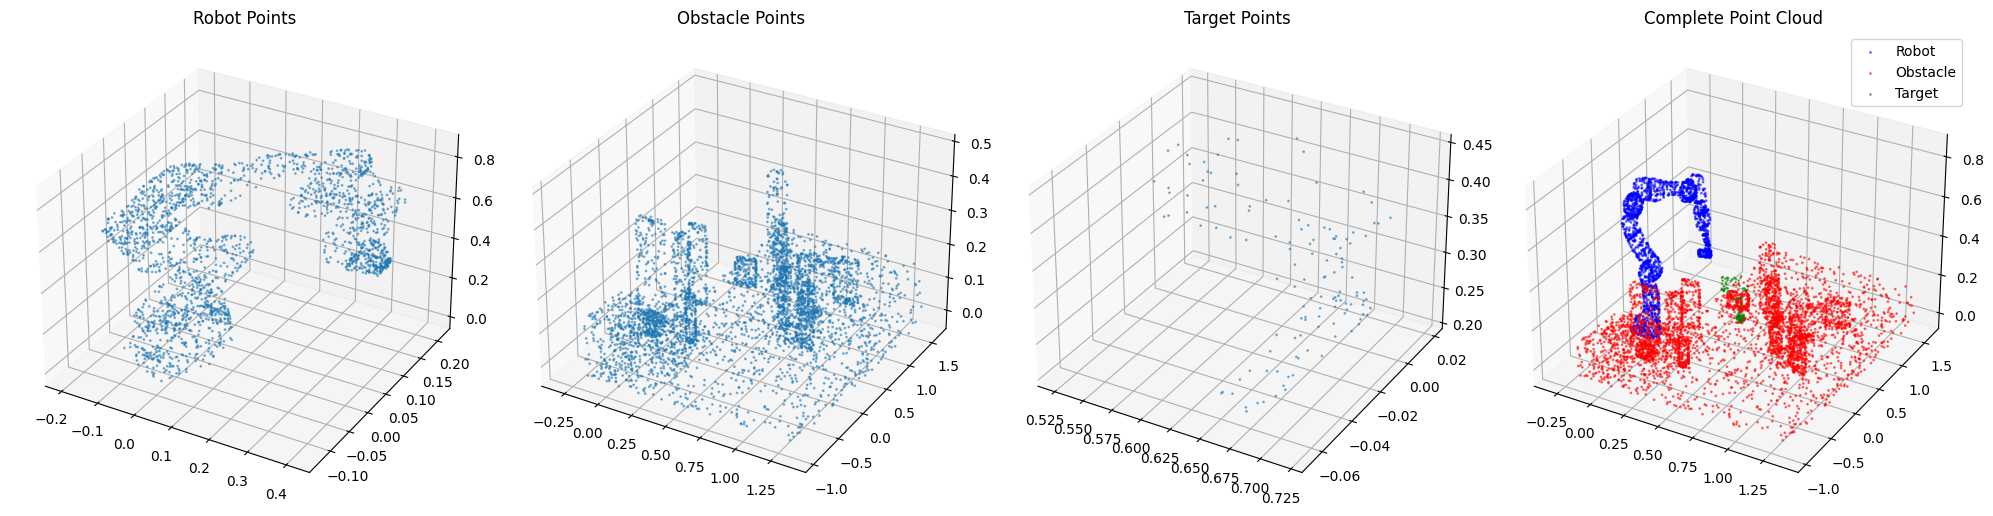

In [14]:
# Optional: Visualize the point clouds
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def visualize_point_clouds(robot_pts, obstacle_pts, target_pts, complete_pc):
    fig = plt.figure(figsize=(20, 5))

    # Robot points
    ax1 = fig.add_subplot(141, projection="3d")
    ax1.scatter(
        robot_pts[:, 0].cpu().numpy(),
        robot_pts[:, 1].cpu().numpy(),
        robot_pts[:, 2].cpu().numpy(),
        s=1,
        alpha=0.5,
    )
    ax1.set_title("Robot Points")

    # Obstacle points
    ax2 = fig.add_subplot(142, projection="3d")
    if len(obstacle_pts) > NUM_OBSTACLE_POINTS:
        sampled_obs = obstacle_pts[
            np.random.choice(
                len(obstacle_pts), min(1000, len(obstacle_pts)), replace=False
            )
        ]
    else:
        sampled_obs = obstacle_pts
    ax2.scatter(sampled_obs[:, 0], sampled_obs[:, 1], sampled_obs[:, 2], s=1, alpha=0.5)
    ax2.set_title("Obstacle Points")

    # Target points
    ax3 = fig.add_subplot(143, projection="3d")
    ax3.scatter(
        target_pts[:, 0].cpu().numpy(),
        target_pts[:, 1].cpu().numpy(),
        target_pts[:, 2].cpu().numpy(),
        s=1,
        alpha=0.5,
    )
    ax3.set_title("Target Points")

    # Complete point cloud
    ax4 = fig.add_subplot(144, projection="3d")
    # Color by label
    robot_mask = complete_pc[:, 3] == 0
    obstacle_mask = complete_pc[:, 3] == 1
    target_mask = complete_pc[:, 3] == 2

    ax4.scatter(
        complete_pc[robot_mask, 0].numpy(),
        complete_pc[robot_mask, 1].numpy(),
        complete_pc[robot_mask, 2].numpy(),
        s=1,
        alpha=0.5,
        c="blue",
        label="Robot",
    )
    ax4.scatter(
        complete_pc[obstacle_mask, 0].numpy(),
        complete_pc[obstacle_mask, 1].numpy(),
        complete_pc[obstacle_mask, 2].numpy(),
        s=1,
        alpha=0.5,
        c="red",
        label="Obstacle",
    )
    ax4.scatter(
        complete_pc[target_mask, 0].numpy(),
        complete_pc[target_mask, 1].numpy(),
        complete_pc[target_mask, 2].numpy(),
        s=1,
        alpha=0.5,
        c="green",
        label="Target",
    )
    ax4.set_title("Complete Point Cloud")
    ax4.legend()

    plt.tight_layout()
    plt.show()


# Visualize
visualize_point_clouds(
    robot_points, obstacle_points, target_points, complete_point_cloud
)

In [15]:
import open3d as o3d
import numpy as np


def visualize_point_cloud_open3d(point_cloud, camera_pose=None, point_size=5.0):
    """
    Visualize point cloud using Open3D with scientific aesthetics.

    Args:
        point_cloud: Tensor or array of shape (N, 4) where last column is label
        camera_pose: Optional camera pose (4x4 matrix)
        point_size: Float, size of the rendered points (default: 5.0)
    """
    # --- 1. Data Preparation ---
    if hasattr(point_cloud, "cpu"):
        point_cloud_np = point_cloud.cpu().numpy()
    else:
        point_cloud_np = point_cloud

    # Separate points by label
    robot_points = point_cloud_np[point_cloud_np[:, 3] == 0][:, :3]
    obstacle_points = point_cloud_np[point_cloud_np[:, 3] == 1][:, :3]
    target_points = point_cloud_np[point_cloud_np[:, 3] == 2][:, :3]

    # --- 2. Geometry Creation ---
    pcd_robot = o3d.geometry.PointCloud()
    pcd_obstacle = o3d.geometry.PointCloud()
    pcd_target = o3d.geometry.PointCloud()

    pcd_robot.points = o3d.utility.Vector3dVector(robot_points)
    pcd_obstacle.points = o3d.utility.Vector3dVector(obstacle_points)
    pcd_target.points = o3d.utility.Vector3dVector(target_points)

    # --- 3. Scientific Color Palette ---
    # Using a soft, muted palette (RGB values 0-1)

    # Robot: Muted Light Blue
    color_robot = [0.45, 0.68, 0.78]
    # Obstacle: Sophisticated Gray
    color_obstacle = [0.55, 0.57, 0.62]
    # Target: Muted Orange
    color_target = [0.85, 0.55, 0.35]

    pcd_robot.paint_uniform_color(color_robot)
    pcd_obstacle.paint_uniform_color(color_obstacle)
    pcd_target.paint_uniform_color(color_target)

    # Combine geometries
    combined_pcd = pcd_robot + pcd_obstacle + pcd_target

    # --- 4. Visualization Setup ---
    vis = o3d.visualization.Visualizer()
    vis.create_window(window_name="Point Cloud Visualization", width=1024, height=768)

    vis.add_geometry(combined_pcd)

    # --- 5. Render Options (Aesthetics) ---
    render_option = vis.get_render_option()

    # Set background to White
    render_option.background_color = np.array([1, 1, 1])

    # Set Point Size (Crucial for visibility)
    render_option.point_size = point_size

    # Clean look: hide the coordinate frame axes
    render_option.show_coordinate_frame = False

    # Optional: Turn on lighting for 3D depth perception (makes points look like spheres)
    # render_option.light_on = True

    # --- 6. Camera Control ---
    if camera_pose is not None:
        view_control = vis.get_view_control()
        params = view_control.convert_to_pinhole_camera_parameters()
        # Note: Direct setting of extrinsic might require inverting the matrix
        # depending on your coordinate system conventions (OpenCV vs OpenGL).
        params.extrinsic = camera_pose
        view_control.convert_from_pinhole_camera_parameters(params)

    # Run
    vis.run()
    vis.destroy_window()


# # Example Usage Block (for testing)
# if __name__ == "__main__":
#     # Generate dummy data: 1000 points, x,y,z,label
#     N = 1000
#     points = np.random.rand(N, 4)
#     # Assign random labels (0, 1, 2)
#     points[:, 3] = np.random.randint(0, 3, size=N)

#     visualize_point_cloud_open3d(points, point_size=10.0)

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


In [16]:
import numpy as np


def get_isometric_camera_pose(center=None, distance=2.0):
    """Isometric view camera pose"""
    if center is None:
        center = np.array([0, 0, 0])

    camera_pose = np.eye(4)
    position = np.array([distance, distance, distance])
    camera_pose[:3, 3] = position
    # Looking towards the center
    forward = center - position
    forward = forward / np.linalg.norm(forward)
    camera_pose[:3, 2] = forward
    # Up direction (world up)
    camera_pose[:3, 1] = np.array([0, 0, 1])
    return camera_pose


camera_pose = get_isometric_camera_pose(center=[0,0,0.0], distance=1.5)

# Visualize
visualize_point_cloud_open3d(complete_point_cloud, camera_pose, point_size=5.0)

In [17]:
# New function to save individual robot, obstacle, and target point clouds as ply (no labels)
# New function to save individual robot, obstacle, and target point clouds as ply (no labels)
import trimesh

def save_individual_point_clouds(robot_points, obstacle_points, target_points, prefix="scene"):
    """
    Save robot, obstacle, and target point clouds as separate .ply files (no labels).
    Args:
        robot_points: (N, 3) torch.Tensor or np.ndarray
        obstacle_points: (M, 3) torch.Tensor or np.ndarray
        target_points: (K, 3) torch.Tensor or np.ndarray
        prefix: str, prefix for filenames
    """
    def to_numpy(x):
        if hasattr(x, "cpu"):
            return x.cpu().numpy()
        return x

    robot_np = to_numpy(robot_points)[:, :3]
    obstacle_np = to_numpy(obstacle_points)[:, :3]
    target_np = to_numpy(target_points)[:, :3]

    trimesh.points.PointCloud(robot_np).export(f"{prefix}_robot.ply")
    trimesh.points.PointCloud(obstacle_np).export(f"{prefix}_obstacle.ply")
    trimesh.points.PointCloud(target_np).export(f"{prefix}_target.ply")
    print(f"Saved {prefix}_robot.ply, {prefix}_obstacle.ply, {prefix}_target.ply")

# Example usage:
save_individual_point_clouds(robot_points, obstacle_points, target_points, prefix="")

Saved _robot.ply, _obstacle.ply, _target.ply


In [41]:
# Load from pkl
import pickle
import numpy as np

# # Load the pickle file
# with open('../cubby_tool_neutral_2.pkl', 'rb') as f:
#     data = pickle.load(f)
    
with open('../cubby_tool_4_policy_c.pkl', 'rb') as f:
    data = pickle.load(f)

# Print all top‑level keys
print("Keys in the pickle:", data.keys())

# Show basic info
print(f"\nTrajectory length: {len(data['trajectory'])}")
print(f"Number of obstacles: {len(data['obstacles'])}")
print(f"Tool info: {data['tools']}")
print(f"Initial configuration (q0): {data['q0']}")
print(f"Target pose matrix:\n{np.array(data['target_matrix'])}")

Keys in the pickle: dict_keys(['trajectory', 'obstacles', 'tools', 'q0', 'target_matrix', 'source_expert_pkl', 'model_path'])

Trajectory length: 151
Number of obstacles: 7
Tool info: {'start_tool_dims': [[0.033180445432662964, 0.026861384510993958, 0.08262467384338379], [0.08066578954458237, 0.026857363060116768, 0.02699582278728485], [0.0, 0.0, 0.0]], 'start_tool_offset': [[0.0, 0.0, 0.041312336921691895], [0.030332893133163452, 0.0, 0.06912676244974136], [0.0, 0.0, 0.0]], 'start_tool_quaternion': [[0.995987594127655, -0.06588327139616013, 0.05327579006552696, -0.0288070198148489], [0.995987594127655, -0.06588327139616013, 0.05327579006552696, -0.0288070198148489], [1.0, 0.0, 0.0, 0.0]], 'start_tool_num_primitives': 2, 'target_tool_dims': [[0.033180445432662964, 0.026861384510993958, 0.08262467384338379], [0.08066578954458237, 0.026857363060116768, 0.02699582278728485], [0.0, 0.0, 0.0]], 'target_tool_offset': [[0.0, 0.0, 0.041312336921691895], [0.030332893133163452, 0.0, 0.0691267624

In [106]:
# Initialize the FK sampler
from utils import FrankaSampler

fk_sampler = FrankaSampler("cuda:0", use_cache=True)
tool_raw = data['tools']
obstacles_raw = data['obstacles']
print(f"Length of trajectory: {len(data['trajectory'])}")
q0_tensor = torch.as_tensor(data['trajectory'][30], device="cuda:0").unsqueeze(0)
target_matrix = torch.as_tensor(data['target_matrix'], device="cuda:0")

print(f"q0_tensor: {q0_tensor}")

Length of trajectory: 151
q0_tensor: tensor([[-0.7194, -0.5400,  0.4643, -2.0461,  1.1416,  2.6545,  0.5575]],
       device='cuda:0')


In [107]:
def get_tool_parameters_from_raw(tool_data):
    """
    Extract tool parameters from the raw dictionary saved in the pickle.
    Expects keys: start_tool_dims, start_tool_offset, start_tool_quaternion, start_tool_num_primitives.
    Returns the same structure as the original get_tool_parameters function.
    """
    num_prims = tool_data['start_tool_num_primitives']

    if num_prims == 0:
        # No tool
        return {
            "is_composite": False,
            "tool_dims": [0.0, 0.0, 0.0],
            "tool_offsets": [0.0, 0.0, 0.0],
            "tool_quats": [1.0, 0.0, 0.0, 0.0],
            "tool_num_primitives": 0,
        }
    elif num_prims == 1:
        # Single primitive – return flat lists
        return {
            "is_composite": False,
            "tool_dims": tool_data['start_tool_dims'][0],          # list of 3 floats
            "tool_offsets": tool_data['start_tool_offset'][0],    # list of 3 floats
            "tool_quats": tool_data['start_tool_quaternion'][0],  # list of 4 floats
            "tool_num_primitives": 1,
        }
    else:
        # Composite tool – return list of lists (only the actual primitives)
        return {
            "is_composite": True,
            "tool_dims": tool_data['start_tool_dims'][:num_prims],
            "tool_offsets": tool_data['start_tool_offset'][:num_prims],
            "tool_quats": tool_data['start_tool_quaternion'][:num_prims],
            "tool_num_primitives": num_prims,
        }
        
tool_params = get_tool_parameters_from_raw(tool_raw)

In [108]:
# Sample robot points
robot_points = sample_robot_points(
    fk_sampler, q0_tensor, tool_params, NUM_ROBOT_POINTS
).squeeze(0)

print(f"Robot points shape: {robot_points.shape}")
print(f"First few robot points: {robot_points[:5]}")

Robot points shape: torch.Size([2048, 3])
First few robot points: tensor([[-0.0234,  0.0327,  0.5038],
        [-0.0338,  0.0451,  0.5273],
        [-0.0428,  0.0065,  0.6216],
        [ 0.5754, -0.0540,  0.7275],
        [ 0.4483, -0.0986,  0.7365]], device='cuda:0')


In [109]:
# Construct target point cloud with correct data type

# # Mpve the target position x + 0.4, y-0.2, z - 0.1 for better visibility
# target_pose[0, 3] += 0.3
# target_pose[1, 3] -= 0.2
# target_pose[2, 3] -= 0.1

target_pose_tensor = (
    torch.as_tensor(target_matrix, dtype=torch.float32).cuda().unsqueeze(0)
)

# Sample target points
target_points = sample_target_points(
    fk_sampler, target_pose_tensor, tool_params, NUM_TARGET_POINTS
).squeeze(0)

print(f"Target points shape: {target_points.shape}")
print(f"First few target points: {target_points[:5]}")

Target points shape: torch.Size([128, 3])
First few target points: tensor([[ 0.4696, -0.0187,  0.6680],
        [ 0.5858, -0.0875,  0.6658],
        [ 0.6086, -0.1130,  0.6539],
        [ 0.6224, -0.0997,  0.6569],
        [ 0.5581, -0.0491,  0.6844]], device='cuda:0')


In [110]:
from typing import List, Union, Dict, Any
from geometrout.primitive import Sphere, Cuboid, Cylinder

def dicts_to_geometrout_primitives(primitives_list: List[Dict[str, Any]]) -> List[Union[Sphere, Cuboid, Cylinder]]:
    """
    Convert a list of primitive dictionaries (as produced by primitives_from_dataset_data)
    into a list of geometrout primitive objects.
    """
    result = []
    for prim in primitives_list:
        typ = prim["type"]
        center = prim["center"]                     # [x, y, z]
        quat = prim.get("quaternion", [1.0, 0.0, 0.0, 0.0])  # fallback identity

        if typ == "cuboid":
            dims = prim["dims"]                      # [dx, dy, dz]
            # Adjust constructor if needed
            result.append(Cuboid(center=center, dims=dims, quaternion=quat))

        elif typ == "cylinder":
            radius, height = prim["dims"]            # [radius, height]
            result.append(Cylinder(center=center, radius=radius, height=height, quaternion=quat))

        elif typ == "sphere":
            # If sphere, dims might be [radius] or just a float
            radius = prim["dims"][0] if isinstance(prim["dims"], (list, tuple)) else prim["dims"]
            result.append(Sphere(center=center, radius=radius))

        else:
            raise ValueError(f"Unknown primitive type: {typ}")

    return result

In [111]:
# Sample from primitive obstacles
print(f"Raw obstacles data: {obstacles_raw}")
from mpinets.geometry import construct_mixed_point_cloud
obstacles = dicts_to_geometrout_primitives(obstacles_raw)
# print(f"Constructed obstacles data: {obstacles}")

Raw obstacles data: [{'type': 'cuboid', 'center': [0.8285084366798401, -0.01239779219031334, 0.40807828307151794], 'dims': [0.018497221171855927, 1.4191114902496338, 0.8161565661430359], 'quaternion': [0.9995368719100952, 0.0, 0.0, -0.030430972576141357]}, {'type': 'cuboid', 'center': [0.6861661076545715, -0.003722506109625101, 0.023902861401438713], 'dims': [0.285212904214859, 1.4191114902496338, 0.018497221171855927], 'quaternion': [0.9995368719100952, 0.0, 0.0, -0.030430972576141357]}, {'type': 'cuboid', 'center': [0.6861661076545715, -0.003722506109625101, 0.8161565661430359], 'dims': [0.285212904214859, 1.4191114902496338, 0.018497221171855927], 'quaternion': [0.9995368719100952, 0.0, 0.0, -0.030430972576141357]}, {'type': 'cuboid', 'center': [0.643001139163971, -0.7119640707969666, 0.4200296998023987], 'dims': [0.285212904214859, 0.018497221171855927, 0.8107509016990662], 'quaternion': [0.9995368719100952, 0.0, 0.0, -0.030430972576141357]}, {'type': 'cuboid', 'center': [0.7293310

In [112]:
obstacle_points = construct_mixed_point_cloud(
    obstacles, NUM_OBSTACLE_POINTS
)
print(f"Constructed obstacle point cloud with shape: {obstacle_points.shape}")

print(f"First few obstacle points: {obstacle_points[:5]}")

Constructed obstacle point cloud with shape: (4096, 4)
First few obstacle points: [[ 5.62483547e-01  1.13026754e-03  7.63545959e-01  6.00000000e+00]
 [ 7.39991702e-01 -2.82198007e-02  6.37647202e-02  6.00000000e+00]
 [ 7.82610112e-01 -2.96721661e-01  4.82646015e-01  1.00000000e+00]
 [ 7.55068708e-01 -4.04757433e-01  4.64148793e-01  1.00000000e+00]
 [ 7.78259374e-01 -3.05520866e-02  1.80028959e-01  6.00000000e+00]]


In [113]:
# Now let's create the complete point cloud as done in run_inference.py
def create_complete_point_cloud(robot_pts, obstacle_pts, target_pts):
    """Create the complete point cloud with labels"""
    xyz = torch.cat(
        (
            torch.zeros(NUM_ROBOT_POINTS, 4),
            torch.ones(NUM_OBSTACLE_POINTS, 4),
            2 * torch.ones(NUM_TARGET_POINTS, 4),
        ),
        dim=0,
    )
    xyz[:NUM_ROBOT_POINTS, :3] = robot_pts.float()

    # For obstacle points, if we have more than needed, sample randomly
    if len(obstacle_pts) > NUM_OBSTACLE_POINTS:
        random_indices = np.random.choice(
            len(obstacle_pts), size=NUM_OBSTACLE_POINTS, replace=False
        )
        obstacle_pts_sampled = obstacle_pts[random_indices]
    else:
        obstacle_pts_sampled = obstacle_pts

    xyz[NUM_ROBOT_POINTS : NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS, :3] = (
        torch.as_tensor(obstacle_pts_sampled[:, :3]).float()
    )
    xyz[NUM_ROBOT_POINTS + NUM_OBSTACLE_POINTS :, :3] = target_pts.float()

    return xyz


# Create the complete point cloud
complete_point_cloud = create_complete_point_cloud(
    robot_points, obstacle_points, target_points
)
print(f"Complete point cloud shape: {complete_point_cloud.shape}")



Complete point cloud shape: torch.Size([6272, 4])


In [114]:
# Optional: Visualize the point clouds
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D


def visualize_point_clouds(robot_pts, obstacle_pts, target_pts, complete_pc):
    fig = plt.figure(figsize=(20, 5))

    # Robot points
    ax1 = fig.add_subplot(141, projection="3d")
    ax1.scatter(
        robot_pts[:, 0].cpu().numpy(),
        robot_pts[:, 1].cpu().numpy(),
        robot_pts[:, 2].cpu().numpy(),
        s=1,
        alpha=0.5,import numpy as np


def get_isometric_camera_pose(center=None, distance=2.0):
    """Isometric view camera pose"""
    if center is None:
        center = np.array([0, 0, 0])

    camera_pose = np.eye(4)
    position = np.array([distance, distance, distance])
    camera_pose[:3, 3] = position
    # Looking towards the center
    forward = center - position
    forward = forward / np.linalg.norm(forward)
    camera_pose[:3, 2] = forward
    # Up direction (world up)
    camera_pose[:3, 1] = np.array([0, 0, 1])
    return camera_pose


camera_pose = get_isometric_camera_pose(center=[0,0,0.0], distance=1.5)

# Visualize
visualize_point_cloud_open3d(complete_point_cloud, camera_pose, point_size=5.0)
    )
    ax1.set_title("Robot Points")

    # Obstacle points
    ax2 = fig.add_subplot(142, projection="3d")
    if len(obstacle_pts) > NUM_OBSTACLE_POINTS:
        sampled_obs = obstacle_pts[
            np.random.choice(
                len(obstacle_pts), min(1000, len(obstacle_pts)), replace=False
            )
        ]
    else:
        sampled_obs = obstacle_pts
    ax2.scatter(sampled_obs[:, 0], sampled_obs[:, 1], sampled_obs[:, 2], s=1, alpha=0.5)
    ax2.set_title("Obstacle Points")

    # Target points
    ax3 = fig.add_subplot(143, projection="3d")
    ax3.scatter(
        target_pts[:, 0].cpu().numpy(),
        target_pts[:, 1].cpu().numpy(),
        target_pts[:, 2].cpu().numpy(),
        s=1,
        alpha=0.5,
    )
    ax3.set_title("Target Points")

    # Complete point cloud
    ax4 = fig.add_subplot(144, projection="3d")
    # Color by label
    robot_mask = complete_pc[:, 3] == 0
    obstacle_mask = complete_pc[:, 3] == 1
    target_mask = complete_pc[:, 3] == 2

    ax4.scatter(
        complete_pc[robot_mask, 0].numpy(),
        complete_pc[robot_mask, 1].numpy(),
        complete_pc[robot_mask, 2].numpy(),
        s=1,
        alpha=0.5,
        c="blue",
        label="Robot",
    )
    ax4.scatter(
        complete_pc[obstacle_mask, 0].numpy(),
        complete_pc[obstacle_mask, 1].numpy(),
        complete_pc[obstacle_mask, 2].numpy(),
        s=1,
        alpha=0.5,
        c="red",
        label="Obstacle",
    )
    ax4.scatter(
        complete_pc[target_mask, 0].numpy(),
        complete_pc[target_mask, 1].numpy(),
        complete_pc[target_mask, 2].numpy(),
        s=1,
        alpha=0.5,
        c="green",
        label="Target",
    )
    ax4.set_title("Complete Point Cloud")
    ax4.legend()

    plt.tight_layout()
    plt.show()


# Visualize
visualize_point_clouds(
    robot_points, obstacle_points, target_points, complete_point_cloud
)

SyntaxError: invalid syntax (3439508635.py, line 16)

In [115]:
import numpy as np


def get_isometric_camera_pose(center=None, distance=2.0):
    """Isometric view camera pose"""
    if center is None:
        center = np.array([0, 0, 0])

    camera_pose = np.eye(4)
    position = np.array([distance, distance, distance])
    camera_pose[:3, 3] = position
    # Looking towards the center
    forward = center - position
    forward = forward / np.linalg.norm(forward)
    camera_pose[:3, 2] = forward
    # Up direction (world up)
    camera_pose[:3, 1] = np.array([0, 0, 1])
    return camera_pose


camera_pose = get_isometric_camera_pose(center=[0,0,0.0], distance=1.5)

# Visualize
visualize_point_cloud_open3d(complete_point_cloud, camera_pose, point_size=5.0)

In [ ]:
# New function to save individual robot, obstacle, and target point clouds as ply (no labels)
# New function to save individual robot, obstacle, and target point clouds as ply (no labels)
import trimesh

def save_individual_point_clouds(robot_points, obstacle_points, target_points, prefix="scene"):
    """
    Save robot, obstacle, and target point clouds as separate .ply files (no labels).
    Args:
        robot_points: (N, 3) torch.Tensor or np.ndarray
        obstacle_points: (M, 3) torch.Tensor or np.ndarray
        target_points: (K, 3) torch.Tensor or np.ndarray
        prefix: str, prefix for filenames 
    """
    def to_numpy(x):
        if hasattr(x, "cpu"):
            return x.cpu().numpy()
        return x

    robot_np = to_numpy(robot_points)[:, :3]
    obstacle_np = to_numpy(obstacle_points)[:, :3]
    target_np = to_numpy(target_points)[:, :3]

    trimesh.points.PointCloud(robot_np).export(f"{prefix}_robot.ply")
    trimesh.points.PointCloud(obstacle_np).export(f"{prefix}_obstacle.ply")
    trimesh.points.PointCloud(target_np).export(f"{prefix}_target.ply")
    print(f"Saved {prefix}_robot.ply, {prefix}_obstacle.ply, {prefix}_target.ply")

# Example usage:
save_individual_point_clouds(robot_points, obstacle_points, target_points, prefix="")

Saved _robot.ply, _obstacle.ply, _target.ply
